# Arabic poetry Transformer

This notebook breaks down the complete **Transformer training** pipeline on **arabic poetry dataset** (**الشعر العربي**) . Each section introduces a key concept with simple mathematical examples before the full implementation.

## What You'll implement:
1. **Tokenization**: Converting text to numbers
2. **Embeddings**: Representing tokens and positions as vectors
3. **Self-Attention**: How tokens pay attention to each other
4. **Multi-Head Attention**: Multiple perspectives on attention
5. **Feed-Forward Networks**: Non-linear transformations
6. **Transformer Blocks**: Combining attention + feed-forward
7. **Full Training**: End-to-end model training
8. **Generation**: Creating new arabic poetry text

**Objective**: Train a character-level transformer to generate arabic poetry in ~2 minutes!

![transformer_architecture](https://github.com/tanjeffreyz/attention-is-all-you-need/raw/main/docs/architecture.png)

However, you should note that this transformer in this notebook, is a unidirectional context decoder-only model like GPT models, contrary to encoder-only (like BERT for instance) or encoder-decoder (e.g., Google T5) models

## 1️⃣ Setup and GPU Verification

First, let's verify we have GPU access and import all necessary libraries.

**In Google Colab :**
1. Click `Runtime` menu (top left)
2. Select `Change runtime type`
3. Choose `GPU` (T4)
4. Click `Save`


**GPU is recommended for faster training, CPU will work but it's slower**

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import time
import sys
import os
import gdown

### **GPU** verification

In [2]:
print(f"Using GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\n✓ Device selected: {device.upper()}")
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Using GPU: Tesla T4
CUDA Available: True
Memory Allocated: 0.00 MB

✓ Device selected: CUDA
Fri May 15 21:00:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |     

## 2️⃣ Data Loading and Tokenization

**Concept**: Convert raw text into tokens, since it's a character-level tokenization, tokens will be represented as integers and then will be processed before training of the neural network.

**Process**:
- Load text file
- Extract unique characters → vocabulary
- Create mappings: character→index (string to integer : **stoi**) and index→character (integer to string : **itos**)
- Encode entire text to integer tensor

In [3]:
# Simple example: tokenizing a short string
simple_text = "مرحبا"
chars = sorted(list(set(simple_text)))
print(f"Unique characters: {chars}")
print(f"Vocabulary size: {len(chars)}\n")

# Create mappings
stoi = {ch: i for i, ch in enumerate(chars)}  # char → index
itos = {i: ch for i, ch in enumerate(chars)}  # index → char

print("Character to Index (stoi):")
print(stoi)
print("\nIndex to Character (itos):")
print(itos)

# Encoding and decoding
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

encoded = encode("مرحبا")
print(f"\nEncoded 'مرحبا': {encoded}")
print(f"Decoded back: {decode(encoded)}")

Unique characters: ['ا', 'ب', 'ح', 'ر', 'م']
Vocabulary size: 5

Character to Index (stoi):
{'ا': 0, 'ب': 1, 'ح': 2, 'ر': 3, 'م': 4}

Index to Character (itos):
{0: 'ا', 1: 'ب', 2: 'ح', 3: 'ر', 4: 'م'}

Encoded 'مرحبا': [4, 3, 2, 1, 0]
Decoded back: مرحبا


In [4]:
print("Loading arabic poetry text...")
file_id = '1EidHB0RkE8r0JajmaQaBlNXn4rsl-cRg'
output = 'input_arabic_poetry.txt'

if os.path.exists(output):
    os.remove(output)
    print(f"Removed old version of {output} to ensure a clean download.")

print("Downloading dataset from Google Drive...")
gdown.download(id=file_id, output=output, quiet=False)

Loading arabic poetry text...


Downloading...
From: https://drive.google.com/uc?id=1EidHB0RkE8r0JajmaQaBlNXn4rsl-cRg
To: /content/input_arabic_poetry.txt
100%|██████████| 73.0M/73.0M [00:00<00:00, 150MB/s]


'input_arabic_poetry.txt'

In [5]:
# Now you will tokenize the text, build vocabulary, create mappings,
# encode all text to tensor and split into training (90%)/validation(10%)

with open(output, 'r', encoding='utf-8') as f:
    dataset = f.read()

print(f"Text length: {len(dataset)} characters")
print(f"First 200 characters:\n{dataset[:200]}\n")


chars = sorted(list(set(dataset)))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Characters: {chars}\n")


stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])


data = torch.tensor(encode(dataset), dtype=torch.long)
print(f"Encoded data shape: {data.shape}")
print(f"First 50 encoded tokens: {data[:50]}")
print(f"Decoded back: {decode(data[:50].tolist())}")


n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"\nTrain data shape: {train_data.shape}")
print(f"Validation data shape: {val_data.shape}")

Text length: 39565996 characters
First 200 characters:
سلام في الصحيفة من لقيط
الى من بالجزيرة من اياد
بان الليث كسرى قد اتاكم
فلا يشغلكم سوق النقاد
اتاكم منهم ستون الفا
يزجون الكتايب كالجراد
على حنق اتيناكم فهذا
اوان هلاككم كهلاك عاد

يا دار عمرة من محتل

Vocabulary size: 71 unique characters
Characters: ['\x01', '\t', '\n', ' ', '!', '"', '#', '.', '/', '8', ':', '=', 'A', 'C', 'E', 'G', 'H', 'I', 'L', 'M', 'N', 'P', 'Q', 'R', 'T', 'U', '[', ']', 'a', 'o', '\xa0', '«', '»', '،', '؛', '؟', 'ء', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ـ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ى', 'ي', 'ٱ', 'ی', '\u200c']

Encoded data shape: torch.Size([39565996])
First 50 encoded tokens: tensor([49, 61, 37, 62,  3, 58, 67,  3, 37, 61, 51, 43, 67, 58, 39,  3, 62, 63,
         3, 61, 59, 67, 53,  2, 37, 61, 66,  3, 62, 63,  3, 38, 37, 61, 42, 48,
        67, 47, 39,  3, 62, 63,  3, 37, 67, 37, 45,  2, 38, 37])
Decoded back: سلام في الصحيفة 

## 3️⃣ Understanding Embeddings

**Concept**: Embeddings transform discrete token indices into continuous vectors.

We need two types of embeddings:
- **Token Embedding**: Each character gets a unique vector representation
- **Positional Embedding**: Each position in the sequence gets a unique vector

**Why?**
- Token embedding captures semantic meaning
- Positional embedding tells the model "where" each token is in the sequence

In [6]:
# Simple embedding example
print("=" * 60)
print("EMBEDDING EXAMPLE")
print("=" * 60)

# Suppose we have 5 unique characters and want 4-dimensional embeddings
vocab_size_toy = 5
embedding_dim = 4

token_embedding = nn.Embedding(vocab_size_toy, embedding_dim)
print(f"\nToken Embedding layer: vocab_size={vocab_size_toy}, dim={embedding_dim}")
print(f"Parameter shape: {list(token_embedding.parameters())[0].shape}")

# Forward pass: embed tokens [0, 2, 1, 3]
token_indices = torch.tensor([0, 2, 1, 3])
embedded_tokens = token_embedding(token_indices)
print(f"\nToken indices: {token_indices.tolist()}")
print(f"Embedded shape: {embedded_tokens.shape}")
print(f"Embedded vectors:\n{embedded_tokens}")

# Positional embedding
max_seq_length = 8
position_embedding = nn.Embedding(max_seq_length, embedding_dim)
print(f"\n\nPositional Embedding layer: max_length={max_seq_length}, dim={embedding_dim}")

positions = torch.arange(4)  # positions [0, 1, 2, 3]
positional_vectors = position_embedding(positions)
print(f"\nPositions: {positions.tolist()}")
print(f"Positional vectors shape: {positional_vectors.shape}")
print(f"Positional vectors:\n{positional_vectors}")

# Combine: final embeddings = token + position
final_embeddings = embedded_tokens + positional_vectors
print(f"\n\nFinal embeddings (token + position):\n{final_embeddings}")
print(f"Shape: {final_embeddings.shape}")

EMBEDDING EXAMPLE

Token Embedding layer: vocab_size=5, dim=4
Parameter shape: torch.Size([5, 4])

Token indices: [0, 2, 1, 3]
Embedded shape: torch.Size([4, 4])
Embedded vectors:
tensor([[ 1.3262, -1.1528,  0.1797,  0.6342],
        [ 0.6395,  0.1402,  0.7764,  0.8362],
        [-0.5768, -0.4945,  0.9864,  0.7991],
        [-0.6392, -0.3932, -0.3883,  0.7549]], grad_fn=<EmbeddingBackward0>)


Positional Embedding layer: max_length=8, dim=4

Positions: [0, 1, 2, 3]
Positional vectors shape: torch.Size([4, 4])
Positional vectors:
tensor([[-1.1301,  2.2243, -0.1850,  0.6220],
        [ 0.1843,  2.2307,  0.5737, -1.5625],
        [-0.5801,  1.0164, -1.7501,  1.0751],
        [-0.0701,  2.8789, -0.7657, -1.5353]], grad_fn=<EmbeddingBackward0>)


Final embeddings (token + position):
tensor([[ 0.1961,  1.0715, -0.0053,  1.2562],
        [ 0.8239,  2.3710,  1.3501, -0.7263],
        [-1.1569,  0.5219, -0.7637,  1.8743],
        [-0.7093,  2.4857, -1.1541, -0.7805]], grad_fn=<AddBackward0>)
Sh

## 4️⃣ Self-Attention Mechanism Explained

**The Math**:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Where:
- $Q$ = Query (what am I looking for?)
- $K$ = Key (what patterns do I represent?)
- $V$ = Value (what information do I contain?)
- $d_k$ = dimension of keys (for scaling)

**Interpretation**: Each token looks at all tokens and assigns attention weights. The weighted sum of values captures relevant context.

In [7]:
# Simple attention example
print("=" * 60)
print("SELF-ATTENTION EXAMPLE")
print("=" * 60)

# Say we have 3 tokens, each with 2-dimensional embeddings
T = 3  # sequence length
d_k = 2  # key dimension

# Create simple embeddings
x = torch.tensor([
    [1.0, 0.5],   # token 1
    [2.0, 1.0],   # token 2
    [1.5, 2.0],   # token 3
])
print(f"Input embeddings (3 tokens × 2 dims):\n{x}\n")

# Create Query, Key, Value projections
W_q = nn.Linear(d_k, d_k, bias=False)
W_k = nn.Linear(d_k, d_k, bias=False)
W_v = nn.Linear(d_k, d_k, bias=False)

Q = W_q(x)
K = W_k(x)
V = W_v(x)

print(f"Q (Queries):\n{Q}\n")
print(f"K (Keys):\n{K}\n")
print(f"V (Values):\n{V}\n")

# Scaled dot-product attention: softmax(Q @ K^T / sqrt(d_k)) @ V
scores = (Q @ K.T) / (d_k ** 0.5)  # [T, T]
print(f"Attention scores (Q @ K^T / sqrt(d_k)):\n{scores}\n")

# Apply softmax
attention_weights = F.softmax(scores, dim=-1)
print(f"Attention weights (after softmax):\n{attention_weights}\n")

# Apply to values
output = attention_weights @ V
print(f"Attention output:\n{output}\n")

print("Interpretation:")
print(f"- Each row sums to 1 (attention weights)")
print(f"- Token at position i attends to all tokens weighted by attention")
print(f"- Output is weighted combination of values")

SELF-ATTENTION EXAMPLE
Input embeddings (3 tokens × 2 dims):
tensor([[1.0000, 0.5000],
        [2.0000, 1.0000],
        [1.5000, 2.0000]])

Q (Queries):
tensor([[ 0.3614, -0.9267],
        [ 0.7228, -1.8533],
        [ 0.2326, -2.0450]], grad_fn=<MmBackward0>)

K (Keys):
tensor([[0.3429, 0.8378],
        [0.6858, 1.6757],
        [0.3816, 1.9914]], grad_fn=<MmBackward0>)

V (Values):
tensor([[0.6148, 0.4890],
        [1.2296, 0.9779],
        [1.4626, 0.9660]], grad_fn=<MmBackward0>)

Attention scores (Q @ K^T / sqrt(d_k)):
tensor([[-0.4614, -0.9228, -1.2074],
        [-0.9228, -1.8455, -2.4147],
        [-1.1552, -2.3103, -2.8169]], grad_fn=<DivBackward0>)

Attention weights (after softmax):
tensor([[0.4751, 0.2995, 0.2253],
        [0.6164, 0.2450, 0.1386],
        [0.6645, 0.2093, 0.1261]], grad_fn=<SoftmaxBackward0>)

Attention output:
tensor([[0.9900, 0.7429],
        [0.8829, 0.6749],
        [0.8504, 0.6515]], grad_fn=<MmBackward0>)

Interpretation:
- Each row sums to 1 (attent

## 5️⃣ Single Head (Causal) Attention Implementation

In a language model, we use **causal attention** or **masked self-attention** : each token can only look at previous tokens (and itself), since this is a decoder-only transformer, instead of bidirectional model

**Key difference**: We mask future positions with $-\infty$ before softmax → 0 attention to future

**Why is it important ?** : We need to prevent leftward
information flow in the decoder to preserve the auto-regressive property (predicting one word at a time). We implement this inside of scaled dot-product attention by masking out (setting to $-\infty$) all values in the input of the softmax which correspond to illegal connections.

The masked attention formula is essentially:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T + Mask}{\sqrt{d_k}}\right)V$$

Where the Mask is $0$ for allowed positions and $-\infty$ for illegal future positions. Hence, we get lower-triangular matrix attention scores, like this one for instance "life is good" :  

$$\begin{array}{c|ccc}
 & \text{Life} & \text{is} & \text{good} \\
\hline
\text{Life} & 10 & -\infty & -\infty \\
\text{is} & 4 & 12 & -\infty \\
\text{good} & 2 & 9 & 15
\end{array}$$

In [8]:
class Head(nn.Module):
    """One head of self-attention with CAUSAL masking"""

    def __init__(self, head_size, n_embd, block_size, dropout=0.1):
        super().__init__()
        self.head_size = head_size
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # Register triangular mask (causal mask)
        # Tokens can only attend to themselves and previous tokens
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape  # batch, time, channels

        k = self.key(x)      # (B, T, head_size)
        q = self.query(x)    # (B, T, head_size)

        # Compute attention scores
        scores = q @ k.transpose(-2, -1) * (self.head_size ** -0.5)  # (B, T, T)

        # Apply causal mask: mask future positions
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float('-inf'))

        # Softmax
        weights = F.softmax(scores, dim=-1)  # (B, T, T)
        weights = self.dropout(weights)

        # Apply to values
        v = self.value(x)  # (B, T, head_size)
        out = weights @ v  # (B, T, head_size)

        return out

# Test the Head
print("Testing single attention head...")
n_embd_test = 8
head_size_test = 4
block_size_test = 4
batch_size_test = 2

head = Head(head_size_test, n_embd_test, block_size_test, dropout=0.0)
x_test = torch.randn(batch_size_test, block_size_test, n_embd_test)
output_head = head(x_test)
print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output_head.shape}")
print(f"✓ Head working correctly!")

Testing single attention head...
Input shape: torch.Size([2, 4, 8])
Output shape: torch.Size([2, 4, 4])
✓ Head working correctly!


## 6️⃣ Multi-Head Attention

**Concept**: Instead of one attention head, run multiple heads in parallel!

- Each head learns different attention patterns
- Concatenate all heads
- Project back to original dimension

**Formula**:
$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$

$W^O$ ensures that the resulting matrix matches the original input dimensions, making it compatible with the subsequent Add & Norm layers.

In [9]:
class MultiHeadAttention(nn.Module):
    """Multiple heads of self-attention run in parallel"""

    def __init__(self, num_heads, head_size, n_embd, block_size, dropout=0.1):
        super().__init__()
        self.heads = nn.ModuleList([
            Head(head_size, n_embd, block_size, dropout)
            for _ in range(num_heads)
        ])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Run all heads and concatenate
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        # Project back
        out = self.dropout(self.proj(out))
        return out

# Test MultiHeadAttention
print("\nTesting multi-head attention...")
n_heads = 4
num_heads_test = 2
head_size_mha = n_embd_test // num_heads_test

mha = MultiHeadAttention(num_heads_test, head_size_mha, n_embd_test, block_size_test, dropout=0.0)
output_mha = mha(x_test)
print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output_mha.shape}")
print(f"Number of heads: {num_heads_test}")
print(f"Head size: {head_size_mha}")
print(f"✓ Multi-Head Attention working correctly!")


Testing multi-head attention...
Input shape: torch.Size([2, 4, 8])
Output shape: torch.Size([2, 4, 8])
Number of heads: 2
Head size: 4
✓ Multi-Head Attention working correctly!


## 7️⃣ Feed-Forward Network

**Purpose**: Add non-linearity and feature transformation between attention layers.

**Architecture**:
1. Linear layer: expand by 4x → `Linear(d, 4d)`
2. ReLU activation → non-linearity
3. Linear layer: project back → `Linear(4d, d)`
4. Dropout for regularization

**Formula**: $$\text{FFN}(x) = \text{Dropout}(\text{Activation}(xW_1 + b_1))W_2 + b_2$$

$*$ Activation might be ReLU or GeLU or other efficient activation function


In [10]:
class FeedForward(nn.Module):
    """Simple feed-forward network with expansion"""

    def __init__(self, n_embd, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),  # Expand
            nn.ReLU(),                      # Non-linearity
            nn.Linear(4 * n_embd, n_embd),  # Project back
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

# Test FeedForward
print("Testing Feed-Forward network...")
ff = FeedForward(n_embd_test, dropout=0.0)
output_ff = ff(x_test)
print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output_ff.shape}")
print(f"Expansion factor: 4x")
print(f"✓ Feed-Forward network working correctly!")

Testing Feed-Forward network...
Input shape: torch.Size([2, 4, 8])
Output shape: torch.Size([2, 4, 8])
Expansion factor: 4x
✓ Feed-Forward network working correctly!


## 8️⃣ Transformer Block

**Concept**: Combine attention + feed-forward with residual connections and layer normalization.

**Architecture**:
1. **Layer Norm** → stabilize inputs
2. **Multi-Head Attention**
3. **Residual Connection** (add input back)
4. **Layer Norm**
5. **Feed-Forward**
6. **Residual Connection** (add input back)

**Formula**:
$$x' = x + \text{Attention}(\text{LayerNorm}(x))$$
$$\text{output} = x' + \text{FFN}(\text{LayerNorm}(x'))$$

In [11]:
class Block(nn.Module):
    """Transformer block: attention + feed-forward with residuals"""

    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        head_size = n_embd // n_head

        self.sa = MultiHeadAttention(n_head, head_size, n_embd, block_size, dropout)
        self.ffwd = FeedForward(n_embd, dropout)

        # Layer normalization (applied before each sublayer)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # Attention with residual connection
        x = x + self.sa(self.ln1(x))

        # Feed-forward with residual connection
        x = x + self.ffwd(self.ln2(x))

        return x

# Test Block
print("\nTesting Transformer Block...")
n_heads_test = 2
block = Block(n_embd_test, n_heads_test, block_size_test, dropout=0.0)
output_block = block(x_test)
print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output_block.shape}")
print(f"✓ Transformer Block working correctly!")


Testing Transformer Block...
Input shape: torch.Size([2, 4, 8])
Output shape: torch.Size([2, 4, 8])
✓ Transformer Block working correctly!


## 9️⃣ Complete Model: ArabicPoetTransformer

**Architecture**:
1. Token Embedding: `vocab_size → n_embd`
2. Position Embedding: `max_length → n_embd`
3. Stack of Transformer Blocks
4. Final Layer Normalization
5. Output Layer: `n_embd → vocab_size` (logits for next character)

In [12]:
# Hyperparameters (already have vocab_size, train_data, val_data from earlier)
batch_size = 64
block_size = 256  # Context length
max_iters = 200
learning_rate = 1e-3
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.1

class ArabicPoetTransformer(nn.Module):
    """Full Arabic Poetry character-level Transformer"""

    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout=0.1):
        super().__init__()
        self.block_size = block_size

        # Token and position embeddings
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        # Stack of transformer blocks
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])

        # Final layer norm and output
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape  # batch, time

        # Embeddings
        tok_emb = self.token_embedding_table(idx)  # (B, T, n_embd)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))  # (T, n_embd)
        x = tok_emb + pos_emb  # broadcast

        # Transformer blocks
        x = self.blocks(x)  # (B, T, n_embd)

        # Final layer norm
        x = self.ln_f(x)

        # Output logits
        logits = self.lm_head(x)  # (B, T, vocab_size)

        # Compute loss if targets provided
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        """Generate new tokens autoregressively"""
        for _ in range(max_new_tokens):
            # Condition on last block_size tokens
            idx_cond = idx[:, -self.block_size:]

            # Get predictions
            logits, _ = self(idx_cond)

            # Get logits for last token
            logits = logits[:, -1, :]  # (B, vocab_size)

            # Convert to probabilities
            probs = F.softmax(logits, dim=-1)

            # Sample next token
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)

            # Append to sequence
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

# Create model and move to device
print("\nInitializing ArabicPoetTransformer...")
print(f"Vocab size: {vocab_size}")
print(f"Model parameters: n_embd={n_embd}, n_head={n_head}, n_layer={n_layer}")
print(f"Block size: {block_size}")

model = ArabicPoetTransformer(vocab_size, n_embd, n_head, n_layer, block_size, dropout)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Test forward pass
print("\nTesting forward pass...")
xb, yb = torch.randint(0, vocab_size, (batch_size, block_size)), torch.randint(0, vocab_size, (batch_size, block_size))
xb, yb = xb.to(device), yb.to(device)
logits, loss = model(xb, yb)
print(f"Logits shape: {logits.shape}")
print(f"Loss: {loss.item():.4f}")
print(f"✓ Model forward pass working!")


Initializing ArabicPoetTransformer...
Vocab size: 71
Model parameters: n_embd=384, n_head=6, n_layer=6
Block size: 256
Total parameters: 10,793,543

Testing forward pass...
Logits shape: torch.Size([16384, 71])
Loss: 4.4392
✓ Model forward pass working!


## 🔟 Data Loading Utility

Before training, we need a function to sample random batches from the data.

In [13]:
def get_batch(split):
    """
    Generate a random batch of data.

    Args:
        split: 'train' or 'val'

    Returns:
        x, y: input tokens and target tokens (shifted by 1)
    """
    data = train_data if split == 'train' else val_data

    # Random starting positions
    ix = torch.randint(len(data) - block_size, (batch_size,))

    # Create sequences
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])

    # Move to device
    x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

    return x, y

# Test get_batch
print("Testing get_batch function...")
xb, yb = get_batch('train')
print(f"Input batch shape: {xb.shape}")
print(f"Target batch shape: {yb.shape}")
print(f"First sequence (decoded): {decode(xb[0, :50].tolist())}")

Testing get_batch function...
Input batch shape: torch.Size([64, 256])
Target batch shape: torch.Size([64, 256])
First sequence (decoded): الله فان ال
حمد مفتاح المزيد

لله در معاشر
غلبوا ا


## 1️⃣1️⃣ Training Loop

**Steps**:
1. Sample batch from training data
2. Forward pass → compute loss
3. Zero gradients
4. Backward pass → compute gradients
5. Optimizer step → update parameters

**Loss Function**: Cross-entropy (measures how wrong predictions are)

In [14]:
# Setup optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Clear GPU cache
torch.cuda.empty_cache()

# Training loop
print("\n" + "=" * 60)
print("Starting Training...")
print("=" * 60 + "\n")

start_time = time.time()
training_losses = []

for iter in range(max_iters):
    # Sample batch
    xb, yb = get_batch('train')

    # Forward pass
    logits, loss = model(xb, yb)

    # Backward pass
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # Log progress
    training_losses.append(loss.item())

    if (iter + 1) % 50 == 0:
        print(f"Step {iter+1}/{max_iters} | Loss: {loss.item():.4f}")

end_time = time.time()
elapsed_time = end_time - start_time

print("\n" + "=" * 60)
print("✓ Training Completed!")
print(f"Total time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
print("=" * 60)


Starting Training...

Step 50/200 | Loss: 2.7491
Step 100/200 | Loss: 2.7120
Step 150/200 | Loss: 2.6799
Step 200/200 | Loss: 2.6906

✓ Training Completed!
Total time: 91.17 seconds (1.52 minutes)


## Visualizing Training Progress

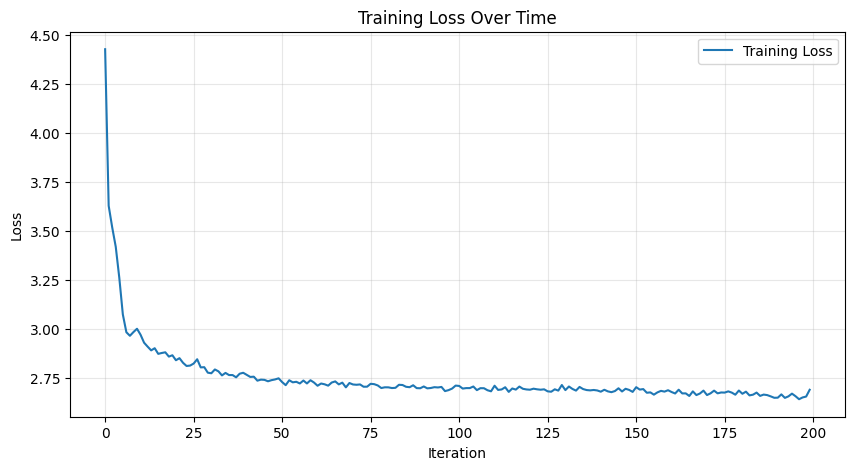


Training Statistics:
Initial loss: 4.4288
Final loss: 2.6906
Loss improvement: 1.7381 (39.2%)


In [15]:
plt.figure(figsize=(10, 5))
plt.plot(training_losses, label='Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nTraining Statistics:")
print(f"Initial loss: {training_losses[0]:.4f}")
print(f"Final loss: {training_losses[-1]:.4f}")
print(f"Loss improvement: {(training_losses[0] - training_losses[-1]):.4f} ({((training_losses[0] - training_losses[-1])/training_losses[0]*100):.1f}%)")

## 1️⃣2️⃣ Text Generation from Trained Model

**Process** (Autoregressive Generation):
1. Start with an empty context (or seed text)
2. Forward pass → get probabilities for next character
3. Sample from probabilities
4. Append to sequence
5. Repeat with new context

In [16]:
# Save the trained model
print("\nSaving model and configuration...")

checkpoint = {
    'model_state_dict': model.state_dict(),
    'vocab_size': vocab_size,
    'n_embd': n_embd,
    'n_head': n_head,
    'n_layer': n_layer,
    'block_size': block_size,
    'dropout': dropout,
    'stoi': stoi,
    'itos': itos,
}

torch.save(checkpoint, 'ArabicPoetTransformer_trained.pt')
print("✓ Model saved to 'ArabicPoetTransformer_trained.pt'\n")

# Generate sample text
print("=" * 60)
print("📜 Generating arabic poetry Text")
print("=" * 60 + "\n")

# Start with empty context
context = torch.zeros((1, 1), dtype=torch.long, device=device)

# Generate 1000 new tokens
generated = model.generate(context, max_new_tokens=1000)[0].tolist()

# Decode and print
generated_text = decode(generated)
print(generated_text)


Saving model and configuration...
✓ Model saved to 'ArabicPoetTransformer_trained.pt'

📜 Generating arabic poetry Text

اه لا يرتحواده
وعلا
لقطها الاس الات كلا ولاعلالتبد
شدا طفاخوها ادا لق صرسعه
فاير
س ا ايها اسره احكم
فسن فقلهورضحد وام كوف كم ته
دهمطيسما لاء
وسياها
مقب
ق ساليا الهدوهط لمنزلولكيد الف م
بافلحاوتعرى اللر نمحبر افيك جلم عناندعنوكاحووقيديه سى
وكى فالى ارق مح فة لن ونكاضى بلود معكيالنوالهمله
ت وقلم
ت
ه
وخقرالد ا لارث اقسالغباحسمجران احبيفاذرجحيسلين بيم
ي الهادودكي ن عان ك
اع ا فنية مه
لوا

ا
احزلي اهام افلعدرقيعد اقالفعه
ما مصله
ا يلاسمومسنيفا توه مثي
طبهال خر ا تحقنهاشا
ين فظربيبلا
وه ا لفنهد اراولى ا ا وارويبين م جلنبوحاء ماه

ودهمرينهد
فيتسك المطلقن تهذا
و لم ا ابه مال ااحمنممين مة وذيبا ا غي
مر ودت ا مغالفكل ذان مثمتقرث ال وقيسله بدت ية غعلريها عي ق ما وم ا
ي ون ميسيرال 
لمالى ان في وان شر مهالهلالانان صحسفافبامد مفيظهواعيثهلباهالش لعدكمزيا باخص من حق لكبمنهلا
يحد و فا لشب
من منقترهلقلو
طلويلكمخلضاليرضا
مم
قدير واق ا بياعص
وج ت الترا 
ومن منتفقدم ياسمرالوجايهما
جفيوس

#### As you might have observed. The text generated by this transformer is meaningless and nonsense. Here's a text generated by this same transformer architecture trained for 1h10min, but with more refined hyperparameter-tuned training :

يهدى تمني للكلاحة نادا

ومن يمنو بين فكر لكل خيض

المن غلبة للمريح ولسا صلاحهم

مولايك وولا حماك انظاحه

وكل شيء احداد شيء يروما

وكانه يناله رماحة اذ حي

تكون الحادثا وانعماحه

سمت عنده الاثا ما رمت به

كل ما عهدته الحب ذا والندوا

ومزحره نهارة الاير منزلا

وغض للمنطقه يعقب ظن

تاءي المناشر كل كل ظاحة

#### This poetry above isn't perfect either, but it shows a slight improvement over the last training

## Key Takeaways

### What you implemented:

1. **Tokenization**: Text → Integers via vocabulary mappings
2. **Embeddings**: Integers → Continuous vectors (token + position)
3. **Self-Attention**: Each token learns which other tokens to focus on
4. **Multi-Head Attention**: Multiple parallel attention mechanisms
5. **Feed-Forward**: Non-linear transformations for feature extraction
6. **Residual Connections**: Adding input to output helps optimization
7. **Layer Normalization**: Stabilizes training
8. **Transformer Block**: Stacking attention + feed-forward layers
9. **Autoregressive Generation**: Sampling tokens one at a time

## Test Your Understanding !

### This section contains questions to test your understanding of Transformers. Answer them to prove you've mastered the concepts!

---

**Q1**: Your Arabic poetry model generates meaningless text. What are methods and changes would you make to improve quality?

I'd train it for longer (higher `max_iter`). Add a learning rate scheduler, early stopping and temperature.

I'd also consider better tokenization.

**Q2**: How to help prevent overfitting?

We train using dropout. We should also get more data whenever we can.

**Q3**: What is the main difference between Token Embedding and Positional Embedding?

A token embedding has semantic value, while a positional embedding is based on the position of the token.

**Q4**: Explain back propagation and feedforward propagation

Backpropagation is our loss value propagating backwards (using the chain rule), this happens to update our weights. As for the feedforward, it is used to compute logits and generate the loss used in the backward prop.

**Q5**: Why do we use **causal masking** in a language model?

We do so to not let tokens attend to tokens occuring after tham. Each token need only attend to its previous tokens.

**Q6**: Explain in one sentence what a Transformer block does.

A block augments its input with context through attention, then inputs that into a feed forward network.

**Q7**: How many attention heads are in our model? What does each head do? Why would we use multiple heads instead of one ?

There are 6 attention heads. Each head independently calculates attention scores, allowing tokens to attend to other tokens in the sequence and draw context from them.

By using multi-head attention, the model can simultaneously focus on different types of relationships in the text.